# Vanilla RNN Seq2Seq — Chemical Reaction Prediction
**Dataset:** USPTO-MIT reaction SMILES  
**Task:** reactants + reagents → product (SMILES string)  
**Architecture:** RNN encoder → RNN decoder (teacher forcing, no attention)

---


## 1  Dependencies

In [1]:
import sys
print(f"Python {sys.version}")
import torch
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")


Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch 2.11.0+cu128  |  CUDA: True


## 2  Global Config

In [2]:
!pip install -q "ray[tune]" "optuna==3.6.1" wandb
!wandb login        # paste your API key once

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 11.7 MB/s eta 0:00:00
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: ERROR Invalid API key: API key may only contain the letters A-Z, digits and underscores.
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file

In [3]:
import os
import wandb
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from dataclasses import dataclass

@dataclass
class Config:
    # data
    data_dir    : str   = "./data"
    save_dir    : str   = "./checkpoints"

    # vocab
    pad_idx     : int   = 0
    sos_idx     : int   = 1
    eos_idx     : int   = 2
    unk_idx     : int   = 3
    vocab_size  : int   = 0        # set after build_vocab()

    # dataloader
    batch_size  : int   = 256
    num_workers : int   = 0
    max_len     : int   = 200      # filter reactions longer than this

    # model
    emb_dim     : int   = 128
    hid_dim     : int   = 512
    n_layers    : int   = 1
    dropout     : float = 0.3

    # training
    epochs      : int   = 10
    lr          : float = 5e-4
    clip        : float = 1.0
    tf_ratio    : float = 0.5     # teacher forcing ratio

cfg = Config()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(cfg.data_dir,  exist_ok=True)
os.makedirs(cfg.save_dir,  exist_ok=True)
print(f"Device: {device}")

Device: cuda


## 3  Special Tokens

In [4]:
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<pad>", "<sos>", "<eos>", "<unk>"
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3


## 4  SMILES Tokeniser

Regex-based character-level tokeniser — handles bracket atoms `[nH]`,
two-char elements `Br`/`Cl`, chirality `@@`, ring closures, etc.


In [5]:
import re
from typing import List

def tokenize(smiles: str) -> list[str]:
    pattern = re.compile(r"""
        \[[^\[\]]+\]  # bracket atoms: [nH], [C@@H], [Na+]
        | Br | Cl     # two-char elements
        | @@          # double chirality (before single @)
        | %\d{2}      # long ring closures: %10, %99
        | [BCFINOPSbcnops@\-=#$:\/\\()\d.*>]  # everything else
    """, re.VERBOSE)
    return ["<sos>"] + pattern.findall(smiles) + ["<eos>"]

# --- Demo ---
test_cases = [
    "CCO.CC(=O)Cl",          # ethanol + acetyl chloride
    "CC(=O)OCC",             # ethyl acetate
    "c1ccccc1",              # benzene (aromatic)
    "[NH4+].[OH-]",          # ions
    "C[C@@H](O)F",           # stereocentre
    "Brc1ccccc1",            # bromobenzene
    "CC(=O)O",
    "[nH]1cccc1",
    "ClC(Br)F",
    "C[C@@H](O)F",
    "CCO.OCC>O>CCOCC",
]

for smi in test_cases:
    print(f"{smi:<25} → {tokenize(smi)}")

CCO.CC(=O)Cl              → ['<sos>', 'C', 'C', 'O', '.', 'C', 'C', '(', '=', 'O', ')', 'Cl', '<eos>']
CC(=O)OCC                 → ['<sos>', 'C', 'C', '(', '=', 'O', ')', 'O', 'C', 'C', '<eos>']
c1ccccc1                  → ['<sos>', 'c', '1', 'c', 'c', 'c', 'c', 'c', '1', '<eos>']
[NH4+].[OH-]              → ['<sos>', '[NH4+]', '.', '[OH-]', '<eos>']
C[C@@H](O)F               → ['<sos>', 'C', '[C@@H]', '(', 'O', ')', 'F', '<eos>']
Brc1ccccc1                → ['<sos>', 'Br', 'c', '1', 'c', 'c', 'c', 'c', 'c', '1', '<eos>']
CC(=O)O                   → ['<sos>', 'C', 'C', '(', '=', 'O', ')', 'O', '<eos>']
[nH]1cccc1                → ['<sos>', '[nH]', '1', 'c', 'c', 'c', 'c', '1', '<eos>']
ClC(Br)F                  → ['<sos>', 'Cl', 'C', '(', 'Br', ')', 'F', '<eos>']
C[C@@H](O)F               → ['<sos>', 'C', '[C@@H]', '(', 'O', ')', 'F', '<eos>']
CCO.OCC>O>CCOCC           → ['<sos>', 'C', 'C', 'O', '.', 'O', 'C', 'C', '>', 'O', '>', 'C', 'C', 'O', 'C', 'C', '<eos>']


## 5  Download & Parse USPTO-MIT

Downloads `data.zip` (~47 MB) from the original Jin et al. repo and extracts
`train.txt`, `valid.txt`, `test.txt` into `./data/`.

Each line is a reaction SMILES:  `reactants>reagents>products`


In [6]:
import re

def remove_atom_map(smiles: str) -> str:
    return re.sub(r":\d+", "", smiles)

In [7]:
import urllib.request, zipfile, io, os
from typing import Tuple, Optional

DATA_ZIP_URL = "https://github.com/wengong-jin/nips17-rexgen/raw/master/USPTO/data.zip"

def download_uspto_mit(data_dir: str = "./data"):
    paths = {}
    splits = ("train", "valid", "test")

    # Check if all files already present
    all_present = all(os.path.exists(os.path.join(data_dir, f"{s}.txt")) for s in splits)
    if all_present:
        print("All split files already present, skipping download.")
        return {s: os.path.join(data_dir, f"{s}.txt") for s in splits}

    print(f"Downloading data.zip from:\n  {DATA_ZIP_URL}")
    with urllib.request.urlopen(DATA_ZIP_URL) as resp:
        zip_bytes = resp.read()
    print(f"  Downloaded {len(zip_bytes)/1e6:.1f} MB")

    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        print("Zip contents:", zf.namelist())
        for name in zf.namelist():
            basename = os.path.basename(name)
            # The zip has files like "data/train.txt" — extract only the .txt splits
            if basename in (f"{s}.txt" for s in splits):
                dest = os.path.join(data_dir, basename)
                with zf.open(name) as src, open(dest, "wb") as dst:
                    dst.write(src.read())
                print(f"  Extracted → {dest}  ({os.path.getsize(dest)/1e6:.1f} MB)")

    return {s: os.path.join(data_dir, f"{s}.txt") for s in splits}

def load_reactions(split: str, data_dir: str = "./data") -> list[tuple[str, str]]:
    path = os.path.join(data_dir, f"{split}.txt")
    pairs = []
    with open(path) as f:
        for line in f:
            line = line.strip().split()[0]   # drop trailing metadata
            if not line:
                continue
            reactants, reagents, products = line.split(">")
            src = remove_atom_map(reactants + ("." + reagents if reagents else ""))
            tgt = remove_atom_map(products)
            pairs.append((src, tgt))
    return pairs

paths = download_uspto_mit(cfg.data_dir)
train = load_reactions("train")
valid = load_reactions("valid")
test  = load_reactions("test")

print(f"train: {len(train):,} | valid: {len(valid):,} | test: {len(test):,}")
print("src:", train[0][0])
print("tgt:", train[0][1])


  https://github.com/wengong-jin/nips17-rexgen/raw/master/USPTO/data.zip
  Downloaded 49.7 MB
Zip contents: ['data/', 'data/test.txt', 'data/train.txt', 'data/valid.txt']
  Extracted → ./data/test.txt  (19.5 MB)
  Extracted → ./data/train.txt  (199.2 MB)
  Extracted → ./data/valid.txt  (14.6 MB)
train: 409,035 | valid: 30,000 | test: 40,000
src: [CH2]([CH]([CH3])[CH3])[Mg+].[CH2]1[O][CH2][CH2][CH2]1.[Cl-].[OH][c]1[n][cH][c]([C](=[O])[N]([O][CH3])[CH3])[cH][cH]1
tgt: [OH][c]1[n][cH][c]([C](=[O])[CH2][CH]([CH3])[CH3])[cH][cH]1


## 6 Build Vocab

In [8]:
def build_vocab(pairs: list[tuple[str, str]]) -> dict:
    special = ["<pad>", "<sos>", "<eos>", "<unk>"]
    tokens  = set()
    for src, tgt in pairs:
        tokens.update(tokenize(src))
        tokens.update(tokenize(tgt))
    vocab = {tok: idx for idx, tok in enumerate(special)}
    for tok in sorted(tokens):
        if tok not in vocab:
            vocab[tok] = len(vocab)
    return vocab

vocab = build_vocab(train)
print(f"vocab size: {len(vocab)}")  # expect ~70-80 tokens
cfg.vocab_size = len(vocab)

vocab size: 309


## 7  Build PyTorch Dataset

In [9]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch

class ReactionDataset(Dataset):
    def __init__(self, pairs: list[tuple[str, str]], vocab: dict):
        self.data  = []
        unk        = vocab["<unk>"]
        for src, tgt in pairs:
            src_ids = [vocab.get(t, unk) for t in tokenize(src)]
            tgt_ids = [vocab["<sos>"]] + [vocab.get(t, unk) for t in tokenize(tgt)] + [vocab["<eos>"]]
            self.data.append((
                torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(tgt_ids, dtype=torch.long),
            ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_pad = pad_sequence(srcs, batch_first=True, padding_value=0)
    tgt_pad = pad_sequence(tgts, batch_first=True, padding_value=0)
    return src_pad, tgt_pad

train_loader = DataLoader(ReactionDataset(train, vocab), batch_size=cfg.batch_size,
                          shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(ReactionDataset(valid, vocab), batch_size=cfg.batch_size,
                          shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(ReactionDataset(test,  vocab), batch_size=cfg.batch_size,
                          shuffle=False, collate_fn=collate_fn)

src_batch, tgt_batch = next(iter(train_loader))
print(f"src: {src_batch.shape}")   # (32, src_len)
print(f"tgt: {tgt_batch.shape}")   # (32, tgt_len)


src: torch.Size([256, 183])
tgt: torch.Size([256, 98])


## 8  Model

```
src tokens ──► Embedding ──► RNN×L ──► hidden
                                           │
tgt tokens ──► Embedding ──► RNN×L ──► Linear ──► logits
```
No attention. Teacher forcing during training.


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.emb     = nn.Embedding(cfg.vocab_size, cfg.emb_dim, padding_idx=cfg.pad_idx)
        self.rnn     = nn.RNN(cfg.emb_dim, cfg.hid_dim, cfg.n_layers,
                              batch_first=True, dropout=cfg.dropout if cfg.n_layers > 1 else 0)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, src):
        # src: (B, src_len)
        return self.rnn(self.dropout(self.emb(src)))  # output, hidden

# ── Decoder ───────────────────────────────────────────────────────────────────

class Decoder(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.emb     = nn.Embedding(cfg.vocab_size, cfg.emb_dim, padding_idx=cfg.pad_idx)
        self.rnn     = nn.RNN(cfg.emb_dim, cfg.hid_dim, cfg.n_layers,
                              batch_first=True, dropout=cfg.dropout if cfg.n_layers > 1 else 0)
        self.fc      = nn.Linear(cfg.hid_dim, cfg.vocab_size)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x, hidden):
        # x: (B, 1)
        out, hidden = self.rnn(self.dropout(self.emb(x)), hidden)
        return self.fc(out.squeeze(1)), hidden   # logits (B, vocab), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder, cfg: Config):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.cfg     = cfg

    def forward(self, src, tgt, teacher_forcing: float = 0.5):
        B, tgt_len  = tgt.shape
        vocab_size  = self.cfg.vocab_size
        outputs     = torch.zeros(B, tgt_len, vocab_size, device=src.device)

        _, hidden   = self.encoder(src)
        inp         = tgt[:, 0].unsqueeze(1)          # <sos>

        for t in range(1, tgt_len):
            logits, hidden  = self.decoder(inp, hidden)
            outputs[:, t]   = logits
            use_teacher     = torch.rand(1).item() < teacher_forcing
            inp = tgt[:, t].unsqueeze(1) if use_teacher \
                  else logits.argmax(1).unsqueeze(1)

        return outputs  # (B, tgt_len, vocab_size)

def build_model(vocab: dict, cfg: Config) -> Seq2Seq:
    """
    Build a Seq2Seq model from vocab and optional hyperparameter overrides.

    Usage:
        model = build_model(vocab)
        model = build_model(vocab, emb_dim=128, hid_dim=256, n_layers=1)
    """
    encoder = Encoder(cfg)
    decoder = Decoder(cfg)
    model   = Seq2Seq(encoder, decoder, cfg)
    print(cfg)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model built — {n_params:,} params | emb={cfg.emb_dim} hid={cfg.hid_dim} layers={cfg.n_layers}")
    return model


def masked_cross_entropy(logits, targets, pad_idx=0):
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(B * T, V), targets.reshape(B * T), ignore_index=pad_idx)



## 9  Training Loop

In [11]:
import math, time
import torch.optim as optim


model = build_model(vocab, cfg).to(device)
optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

def train_epoch(model, loader, tf_ratio):
    model.train()
    total = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt, tf_ratio)          # (B, tgt_len, vocab)
        loss   = masked_cross_entropy(logits[:, 1:], tgt[:, 1:], PAD_IDX)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.clip)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt, teacher_forcing=0)   # (B, tgt_len, vocab)
        total += masked_cross_entropy(logits[:, 1:], tgt[:, 1:], PAD_IDX).item()
    return total / len(loader)


Config(data_dir='./data', save_dir='./checkpoints', pad_idx=0, sos_idx=1, eos_idx=2, unk_idx=3, vocab_size=309, batch_size=256, num_workers=0, max_len=200, emb_dim=128, hid_dim=512, n_layers=1, dropout=0.3, epochs=10, lr=0.0005, clip=1.0, tf_ratio=0.5)
Model built — 895,029 params | emb=128 hid=512 layers=1


# 9.5 Optuna and wandb

In [12]:
import optuna
print(optuna.__version__)

3.6.1


In [13]:
import optuna
import itertools

WANDB_PROJECT = "smiles-hparam-search"
SUBSET_SIZE   = 10_000          # exact number of training samples

# ── fixed 10k subset indices (generated once, reused across all trials) ─────
def get_fixed_indices(dataset_len: int, n: int = SUBSET_SIZE, seed: int = 42):
    rng = np.random.default_rng(seed)
    return rng.choice(dataset_len, size=min(n, dataset_len), replace=False).tolist()

# ── loaders ──────────────────────────────────────────────────────────────────
def get_loaders(cfg: Config, train_indices: list, train_ds, valid_ds):
    train_loader = DataLoader(
        Subset(train_ds, train_indices),
        batch_size=cfg.batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,
        drop_last=True,
    )
    val_loader = DataLoader(
        valid_ds,                        # always full val set
        batch_size=cfg.batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
    )
    return train_loader, val_loader

study = optuna.create_study(direction="minimize")
train_indices = get_fixed_indices(len(train))
train_ds = ReactionDataset(train, vocab)
valid_ds = ReactionDataset(valid, vocab)

def objective(trial):
    cfg = Config(
        hid_dim = trial.suggest_categorical("hid_dim", [128, 256, 512]),
        n_layers = trial.suggest_categorical("n_layers", [1, 2]),
        dropout    = trial.suggest_categorical("dropout",    [0.1, 0.3, 0.5]),
        lr         = trial.suggest_categorical("lr",         [1e-4, 1e-3]),
        tf_ratio   = trial.suggest_categorical("tf_ratio",   [0.1, 0.4, 0.7]),
    )
    cfg.vocab_size = len(vocab)

    run = wandb.init(
        project  = "smiles-hparam-search",
        group    = "optuna",
        name     = f"trial-{trial.number}",
        config   = study.best_params if trial.number > 0 else vars(cfg),
        reinit   = True,
    )

    device    = "cuda" if torch.cuda.is_available() else "cpu"
    model     = build_model(vocab, cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    train_loader, val_loader = get_loaders(cfg, train_indices, train_ds, valid_ds)

    for epoch in range(3):
        tf         = max(0.0, cfg.tf_ratio * (1 - epoch / 3))
        train_loss = train_epoch(model, train_loader, tf)
        val_loss   = evaluate(model, val_loader)
        wandb.log({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    wandb.log({"final_val_loss": val_loss})
    wandb.finish()

    print(f"  trial {trial.number} | val={val_loss:.4f} | "
          f"hidden={cfg.hid_dim} layers={cfg.n_layers} "
          f"lr={cfg.lr} dropout={cfg.dropout} tf={cfg.tf_ratio}")
    return val_loss

# log best config after all trials
study.optimize(objective, n_trials=20)

with wandb.init(project="smiles-hparam-search", name="best-config", group="optuna"):
    wandb.log({"best_val_loss": study.best_value})
    wandb.config.update(study.best_params)

print(f"best val_loss : {study.best_value:.4f}")
print(f"best params   : {study.best_params}")

[I 2026-06-11 21:36:21,004] A new study created in memory with name: no-name-35fd1c82-878b-4fb2-9c85-0b1848880398
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: zhenga10 (zhenga10-uci) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Config(data_dir='./data', save_dir='./checkpoints', pad_idx=0, sos_idx=1, eos_idx=2, unk_idx=3, vocab_size=309, batch_size=256, num_workers=0, max_len=200, emb_dim=128, hid_dim=128, n_layers=1, dropout=0.3, epochs=10, lr=0.001, clip=1.0, tf_ratio=0.7)
Model built — 185,013 params | emb=128 hid=128 layers=1


epoch,▁▅█
final_val_loss,▁
train_loss,▁▄█
val_loss,▁▁▁
epoch,2
final_val_loss,5.81192
train_loss,5.79832
val_loss,5.81192


[I 2026-06-11 21:37:26,299] Trial 0 finished with value: 5.811920618606826 and parameters: {'hid_dim': 128, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'tf_ratio': 0.7}. Best is trial 0 with value: 5.811920618606826.


  trial 0 | val=5.8119 | hidden=128 layers=1 lr=0.001 dropout=0.3 tf=0.7


...

epoch,▁▅█
final_val_loss,▁
train_loss,▁▅█
val_loss,▁▁▁
epoch,2
final_val_loss,5.75246
train_loss,5.76156
val_loss,5.75246


[I 2026-06-11 21:59:40,105] Trial 19 finished with value: 5.752456810514806 and parameters: {'hid_dim': 512, 'n_layers': 2, 'dropout': 0.5, 'lr': 0.0001, 'tf_ratio': 0.1}. Best is trial 7 with value: 5.711158093759569.


  trial 19 | val=5.7525 | hidden=512 layers=2 lr=0.0001 dropout=0.5 tf=0.1


best_val_loss,▁
best_val_loss,5.71116


best val_loss : 5.7112
best params   : {'hid_dim': 256, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.0001, 'tf_ratio': 0.7}


In [14]:
from pathlib import Path

best_cfg            = Config(**study.best_params)
best_cfg.vocab_size = len(vocab)
model     = build_model(vocab, best_cfg).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_cfg.lr)
Path(best_cfg.save_dir).mkdir(parents=True, exist_ok=True)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
best_val_loss = math.inf
history = {"train": [], "val": []}

for epoch in range(1, best_cfg.epochs + 1):
    t0       = time.time()
    tf_ratio = max(0.0, best_cfg.tf_ratio * (1 - epoch / best_cfg.epochs))

    train_loss = train_epoch(model, train_loader, tf_ratio)
    val_loss   = evaluate(model, valid_loader)
    scheduler.step(val_loss)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    flag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({"model_state": model.state_dict(),
                    "vocab":       vocab,
                    "cfg":         best_cfg},
                   Path(best_cfg.save_dir) / "best_model.pt")
        flag = "  ✓ saved"

    print(f"Epoch {epoch:3d}/{best_cfg.epochs} | "
          f"train {train_loss:.4f} (ppl {math.exp(train_loss):.1f}) | "
          f"val {val_loss:.4f} (ppl {math.exp(val_loss):.1f}) | "
          f"{time.time()-t0:.0f}s{flag}")

Config(data_dir='./data', save_dir='./checkpoints', pad_idx=0, sos_idx=1, eos_idx=2, unk_idx=3, vocab_size=309, batch_size=256, num_workers=0, max_len=200, emb_dim=128, hid_dim=256, n_layers=2, dropout=0.3, epochs=10, lr=0.0001, clip=1.0, tf_ratio=0.7)
Model built — 619,317 params | emb=128 hid=256 layers=2
Epoch   1/10 | train 2.1151 (ppl 8.3) | val 3.1062 (ppl 22.3) | 455s  ✓ saved
Epoch   2/10 | train 1.8837 (ppl 6.6) | val 3.2314 (ppl 25.3) | 455s
Epoch   3/10 | train 1.9448 (ppl 7.0) | val 3.2633 (ppl 26.1) | 456s
Epoch   4/10 | train 2.0356 (ppl 7.7) | val 3.1473 (ppl 23.3) | 455s
Epoch   5/10 | train 2.1475 (ppl 8.6) | val 2.8118 (ppl 16.6) | 455s  ✓ saved
Epoch   6/10 | train 2.2653 (ppl 9.6) | val 2.7310 (ppl 15.3) | 458s  ✓ saved
Epoch   7/10 | train 2.3567 (ppl 10.6) | val 2.6664 (ppl 14.4) | 457s  ✓ saved
Epoch   8/10 | train 2.4615 (ppl 11.7) | val 2.6596 (ppl 14.3) | 458s  ✓ saved
Epoch   9/10 | train 2.5570 (ppl 12.9) | val 2.6539 (ppl 14.2) | 458s  ✓ saved
Epoch  10/10 

In [15]:
# 1. What does the loss look like? Should be <2.0 after 3 epochs
print(f"Final train loss: {history['train'][-1]:.4f}")
print(f"Final val loss:   {history['val'][-1]:.4f}")

Final train loss: 2.6555
Final val loss:   2.6513


## 10  Learning Curves

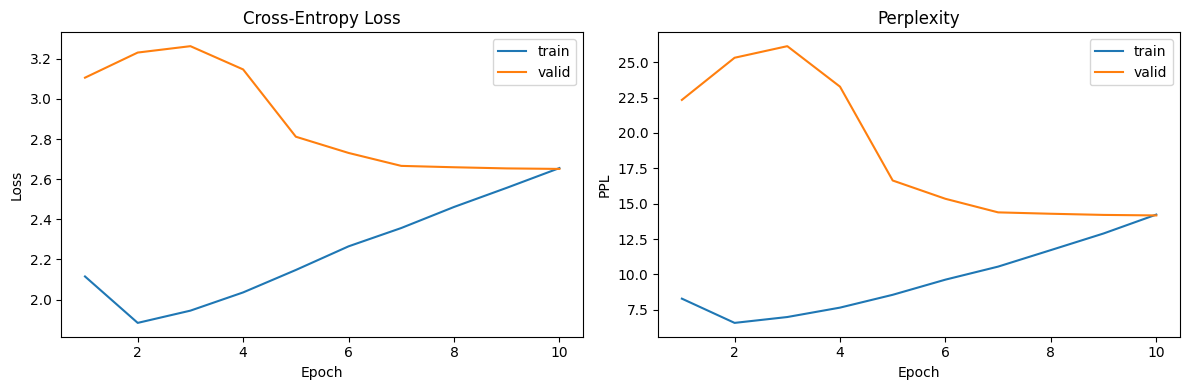

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history["train"]) + 1)

axes[0].plot(epochs_range, history["train"], label="train")
axes[0].plot(epochs_range, history["val"],   label="valid")
axes[0].set(title="Cross-Entropy Loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend()

axes[1].plot(epochs_range, [math.exp(l) for l in history["train"]], label="train")
axes[1].plot(epochs_range, [math.exp(l) for l in history["val"]],   label="valid")
axes[1].set(title="Perplexity", xlabel="Epoch", ylabel="PPL")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11  Test Evaluation — Exact Match Accuracy

In [17]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 20.4 MB/s eta 0:00:00


In [18]:
from rdkit import Chem
from rdkit import RDLogger

SPECIAL   = {cfg.pad_idx, cfg.sos_idx, cfg.eos_idx}
idx2token = {v: k for k, v in vocab.items()}
RDLogger.DisableLog("rdApp.*")

def canonical(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol) if mol else None

@torch.no_grad()
def evaluate_test(n: int = 1000):
    model.eval()
    exact, equiv, invalid, total = 0, 0, 0, 0
    tok_correct, tok_total       = 0, 0

    # ── test loss ────────────────────────────────────────────────────────────
    test_loss = evaluate(model, test_loader)
    print(f"test loss: {test_loss:.4f} (ppl {math.exp(test_loss):.1f})")
    print()

    for src_batch, tgt_batch in test_loader:
        src_batch = src_batch.to(device)

        for i in range(src_batch.size(0)):
            if total >= n:
                break

            # ── decode target ────────────────────────────────────────────────
            tgt_ids = [t.item() for t in tgt_batch[i] if t.item() not in SPECIAL]
            tgt     = "".join(idx2token[t] for t in tgt_ids)

            # ── predict ──────────────────────────────────────────────────────
            src           = src_batch[i].unsqueeze(0)
            _, hidden     = model.encoder(src)
            inp           = torch.tensor([[cfg.sos_idx]], device=device)
            pred_ids, tokens = [], []

            for _ in range(cfg.max_len):
                logits, hidden = model.decoder(inp, hidden)
                tok            = logits.argmax(1).item()
                if tok == cfg.eos_idx:
                    break
                if tok not in SPECIAL:
                    pred_ids.append(tok)
                    tokens.append(idx2token.get(tok, ""))
                inp = torch.tensor([[tok]], device=device)

            pred = "".join(tokens)

            # ── token accuracy ───────────────────────────────────────────────
            min_len      = min(len(pred_ids), len(tgt_ids))
            tok_correct += sum(p == t for p, t in zip(pred_ids, tgt_ids))
            tok_total   += max(len(pred_ids), len(tgt_ids))  # penalise length mismatch

            # ── molecule accuracy ────────────────────────────────────────────
            if pred == tgt:
                exact += 1
            elif canonical(pred) is None:
                invalid += 1
            elif canonical(pred) == canonical(tgt):
                equiv += 1

            # ── print first 5 ────────────────────────────────────────────────
            if total < 5:
                match = "✓ exact" if pred == tgt else \
                        "~ equiv" if (canonical(pred) and canonical(pred) == canonical(tgt)) else \
                        "✗ wrong"
                print(f"[{total+1}] {match}")
                print(f"  tgt:  {tgt[:80]}")
                print(f"  pred: {pred[:80]}")
                print(f"  tok acc: {sum(p==t for p,t in zip(pred_ids,tgt_ids))}/{max(len(pred_ids),len(tgt_ids))}")
                print()

            total += 1

        if total >= n:
            break

    print(f"── results over {total} reactions ──────────────────")
    print(f"token accuracy: {tok_correct/tok_total:.1%}  ({tok_correct}/{tok_total})")
    print(f"exact match:    {exact/total:.1%}  ({exact})")
    print(f"chemically eq:  {equiv/total:.1%}  ({equiv})")
    print(f"total correct:  {(exact+equiv)/total:.1%}  ({exact+equiv})")
    print(f"invalid SMILES: {invalid/total:.1%}  ({invalid})")

evaluate_test()

test loss: 2.6522 (ppl 14.2)

[1] ✗ wrong
  tgt:  [c]1([NH][c]2[s][cH][cH][c]2[C]#[N])[c]([N+](=[O])[O-])[cH][c]([F])[c]([F])[cH]1
  pred: [CH3](11((((((((((((((([cH])[cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH]
  tok acc: 4/58

[2] ✗ wrong
  tgt:  [CH3][c]1[n][n](-[c]2[cH][cH][c]([C]([F])([F])[F])[cH][cH]2)[cH][c]1[CH]([CH2][O
  pred: [CH3](11((((((((((((((([cH])[cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH]
  tok acc: 12/61

[3] ✗ wrong
  tgt:  [ClH].[NH]([CH]1[CH]([OH])[CH2][N]([CH2][CH]2[CH2][n]3[c]4[c]2[c]([F])[cH][n][c]
  pred: [CH3](11((((((((((((((([cH])[cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH]
  tok acc: 7/58

[4] ✗ wrong
  tgt:  [O]([c]1[cH][cH][c]([N]2[C](=[O])[C](=[C]([CH3])[c]3[c]([CH3])[s][c](-[c]4[cH][c
  pred: [CH3](11((((((((((((((([cH])[cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH][cH]
  tok acc: 12/73

[5] ✗ wrong
  tgt:  [Cl][c]1[c]([CH2][O][CH]2[O][CH2][CH2][CH2][CH2]2)[c]([CH2][OH])[cH][n][cH]1
  pred: [CH3](11((((((((((((((([cH])[cH][cH

In [19]:
@torch.no_grad()
def token_accuracy(model, loader, max_batches=50):
    model.eval()
    correct = total = 0
    for i, (src, tgt) in enumerate(loader):
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt, teacher_forcing=0.0)  # (B, T, V)
        preds  = logits[:, 1:].argmax(-1)              # (B, T-1)
        mask   = tgt[:, 1:] != cfg.pad_idx
        correct += (preds[mask] == tgt[:, 1:][mask]).sum().item()
        total   += mask.sum().item()
        if i >= max_batches:
            break
    return correct / total

acc = token_accuracy(model, test_loader)
print(f"token accuracy: {acc*100:.1f}%")

token accuracy: 18.1%
